In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import trim_mean

In [7]:
# 1. Configuración de variables globales
TOTAL_REGISTROS = 1048575 
MUESTRA_SECUENCIAL = 20000

In [8]:
df_sec = pd.read_csv('../../cmd/secuential_cleaner/metricas_secuencial_100.csv')
df_conc = pd.read_csv('../../cmd/concurrent_cleaner/metricas_concurrente.csv')

##### ANÁLISIS SECUENCIAL (BASELINE PROYECTADO)

In [9]:
# Calculamos la media recortada al 10% (0.1 por cada lado = 20% de datos descartados)
media_recortada_sec_muestra = trim_mean(df_sec['tiempo_segundos'], 0.1)

# Proyectamos el tiempo para el dataset completo
tiempo_secuencial_total = (media_recortada_sec_muestra / MUESTRA_SECUENCIAL) * TOTAL_REGISTROS

print(f"--- MÉTRICAS SECUENCIALES ---")
print(f"Media recortada (20k registros): {media_recortada_sec_muestra:.4f} s")
print(f"Tiempo Proyectado ({TOTAL_REGISTROS} registros): {tiempo_secuencial_total:.4f} s\n")

--- MÉTRICAS SECUENCIALES ---
Media recortada (20k registros): 26.3382 s
Tiempo Proyectado (1048575 registros): 1380.8768 s



#### ANÁLISIS CONCURRENTE Y COMPARATIVA

In [10]:
# Agrupamos por cantidad de workers y sacamos la media recortada de cada grupo
resultados = df_conc.groupby('workers')['tiempo_segundos'].apply(lambda x: trim_mean(x, 0.1)).reset_index()
resultados.rename(columns={'tiempo_segundos': 'tiempo_concurrente'}, inplace=True)

# 1. Calcular Speedup (Qué tan rápido es vs el secuencial proyectado)
resultados['speedup'] = tiempo_secuencial_total / resultados['tiempo_concurrente']

# 2. Calcular Scalability / Eficiencia (Speedup / cantidad de workers)
# Se expresa en porcentaje. El ideal teórico es 100% (aumento lineal perfecto).
resultados['eficiencia_%'] = (resultados['speedup'] / resultados['workers']) * 100

# 3. Calcular Trade-offs (Ganancia Marginal)
# Cuántos segundos extra me ahorro al subir al siguiente escalón de workers
resultados['segundos_ahorrados'] = resultados['tiempo_concurrente'].diff().abs()
# El primer valor es el ahorro respecto al secuencial
resultados.loc[0, 'segundos_ahorrados'] = tiempo_secuencial_total - resultados.loc[0, 'tiempo_concurrente']

#### TABLA DE RESULTADOS

In [11]:
print(resultados.to_string(index=False, float_format="%.4f"))

 workers  tiempo_concurrente  speedup  eficiencia_%  segundos_ahorrados
      15             98.3457  14.0411       93.6070           1282.5311
      30             49.1614  28.0886       93.6287             49.1842
      45             32.7967  42.1041       93.5646             16.3647
      60             23.8344  57.9363       96.5605              8.9623
      75             18.7201  73.7642       98.3523              5.1142
      90             15.5325  88.9026       98.7807              3.1877
     105             13.9017  99.3313       94.6012              1.6307
     120             12.1994 113.1920       94.3267              1.7023
     135             10.7609 128.3230       95.0541              1.4385
     150              9.5940 143.9314       95.9543              1.1670


#### GRAFICOS

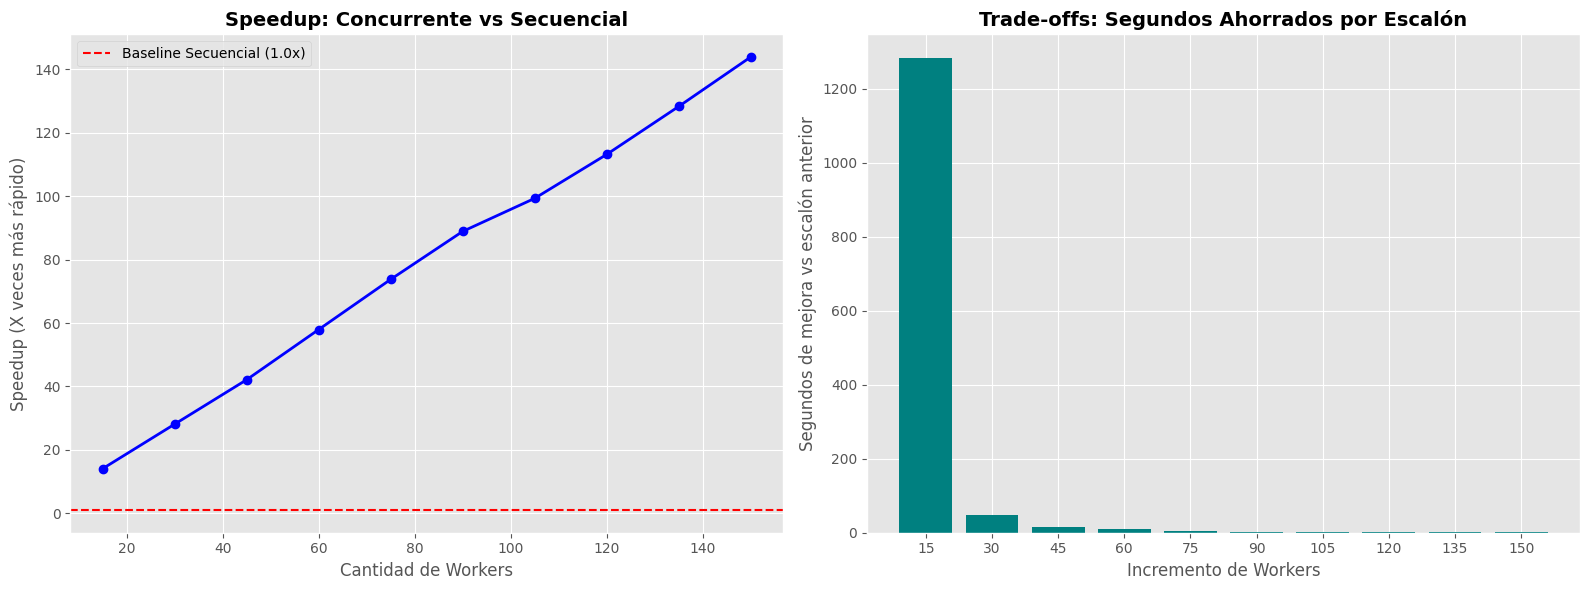

In [14]:
plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Curva de Speedup
ax1.plot(resultados['workers'], resultados['speedup'], marker='o', color='b', linewidth=2)
ax1.set_title('Speedup: Concurrente vs Secuencial', fontsize=14, fontweight='bold')
ax1.set_xlabel('Cantidad de Workers', fontsize=12)
ax1.set_ylabel('Speedup (X veces más rápido)', fontsize=12)
ax1.axhline(y=1, color='r', linestyle='--', label='Baseline Secuencial (1.0x)')
ax1.legend()

# Gráfico 2: Trade-offs (Ganancia Marginal)
bars = ax2.bar(resultados['workers'].astype(str), resultados['segundos_ahorrados'], color='teal')
ax2.set_title('Trade-offs: Segundos Ahorrados por Escalón', fontsize=14, fontweight='bold')
ax2.set_xlabel('Incremento de Workers', fontsize=12)
ax2.set_ylabel('Segundos de mejora vs escalón anterior', fontsize=12)

plt.tight_layout()
plt.show()